<a href="https://colab.research.google.com/github/gandharvbharde25/pitchiq/blob/master/exp%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.xlsx to dataset (1).xlsx


Dataset shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    

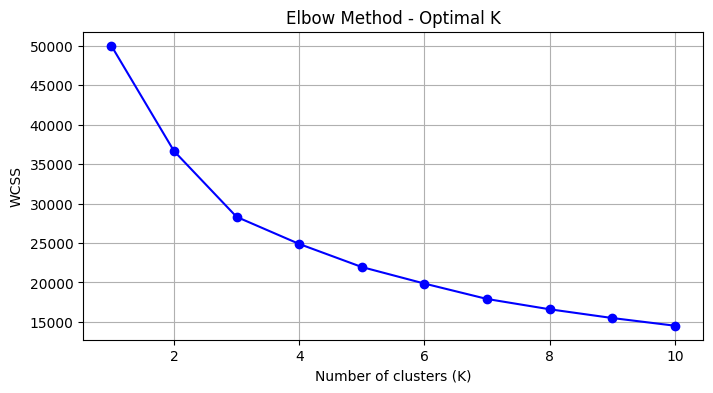


Cluster sizes:
Cluster
1    4017
0    3930
2    2053
Name: count, dtype: int64


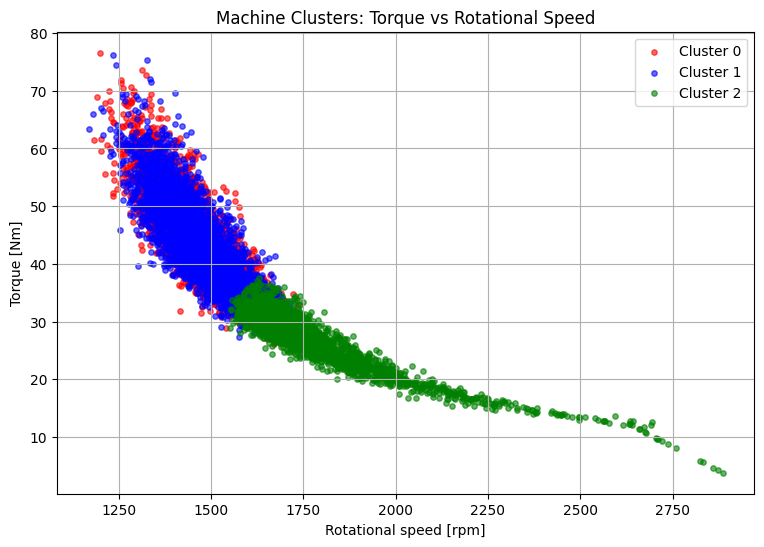


Mean values per cluster:
         Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
Cluster                                                                         
0                     301.72                   311.25                 1469.81   
1                     298.26                   308.74                 1474.14   
2                     300.12                   310.10                 1797.26   

         Torque [Nm]  Tool wear [min]  
Cluster                                
0              43.64           110.36  
1              43.26           104.62  
2              26.57           109.85  


In [2]:
# ============================================================
# EXPERIMENT 1 - PART A: UNSUPERVISED LEARNING (K-MEANS)
# Goal: Group machines by their operating behavior
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_excel('dataset.xlsx')
df = df.drop(columns=['Unnamed: 0'])   # remove extra index column
print("Dataset shape:", df.shape)
print(df.head())

# Select sensor features for clustering
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
X = df[features].values

# Standardize features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- Elbow Method: find best K ----------
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, 'bo-')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# ---------- Apply K-Means with K=3 ----------
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

print("\nCluster sizes:")
print(df['Cluster'].value_counts())

# ---------- Visualize clusters (Torque vs Rotational speed) ----------
plt.figure(figsize=(9, 6))
colors = ['red', 'blue', 'green']
for i in range(3):
    sub = df[df['Cluster'] == i]
    plt.scatter(sub['Rotational speed [rpm]'], sub['Torque [Nm]'],
                s=15, c=colors[i], label=f'Cluster {i}', alpha=0.6)
plt.title('Machine Clusters: Torque vs Rotational Speed')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.grid(True)
plt.show()

print("\nMean values per cluster:")
print(df.groupby('Cluster')[features].mean().round(2))

Accuracy: 0.9592

Confusion Matrix:
[[2386   29]
 [  73   12]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.99      0.98      2415
     Failure       0.29      0.14      0.19        85

    accuracy                           0.96      2500
   macro avg       0.63      0.56      0.58      2500
weighted avg       0.95      0.96      0.95      2500



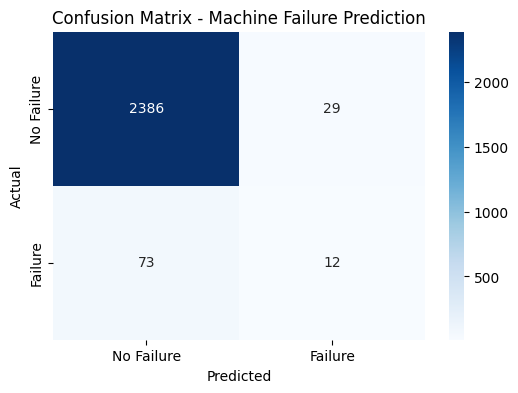


Prediction for new reading: NO FAILURE


In [3]:
# ============================================================
# EXPERIMENT 1 - PART B: SUPERVISED LEARNING (NAIVE BAYES)
# Goal: Classify whether a machine will fail or not
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)
import seaborn as sns

# Features (X) and target (y)
X = df[features].values
y = df['Machine failure'].values        # 0 = OK, 1 = Failed

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Split into train / test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Train Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
       target_names=['No Failure', 'Failure']))

# Visualize confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.title('Confusion Matrix - Machine Failure Prediction')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

# Test on a sample new reading
sample = np.array([[300, 310, 1500, 40, 100]])   # [AirT, ProcT, RPM, Torque, ToolWear]
sample_scaled = StandardScaler().fit(X).transform(sample)
pred = model.predict(sample_scaled)
print(f"\nPrediction for new reading: {'FAILURE' if pred[0]==1 else 'NO FAILURE'}")